# 123. 射影カスケード: Voronoi + 射影ベース枝刈りの組み合わせ

## 目的
- NB122で評価した射影フィルタのうち、Pareto最適な手法をVoronoiと組み合わせたカスケード検索を構築
- 複数フィルタの組み合わせ（AND/OR）、適応的閾値調整を検証
- **問い**: Voronoi + 射影フィルタのカスケードで候補をさらに削減できるか？

## 0. セットアップ

In [1]:
import sys
import numpy as np
import pickle
import time
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from itq_lsh import ITQLSH, hamming_distance_batch

DATA_DIR = Path('../data')
rng = np.random.default_rng(42)

N_QUERIES = 200
TOP_K = 10
print(f'Configuration: N_QUERIES={N_QUERIES}, TOP_K={TOP_K}')

Configuration: N_QUERIES=200, TOP_K=10


In [2]:
# データロード
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-10, None)

emb_en = normalize(np.load(DATA_DIR / '10k_e5_base_en_embeddings.npy'))
emb_ja = normalize(np.load(DATA_DIR / '10k_e5_base_ja_embeddings.npy'))
centroids = normalize(np.load(DATA_DIR / 'voronoi_centroids_256_e5base_mixed.npy'))

proj_data = np.load(DATA_DIR / '121_projection_analysis.npz')
R = proj_data['rotation_matrix']
pca_components = proj_data['pca_components']

hashes_en = np.load(DATA_DIR / '10k_e5_base_en_hashes_128bits.npy')

# NB122の結果
with open(DATA_DIR / '122_pruning_results.pkl', 'rb') as f:
    nb122_data = pickle.load(f)

D = emb_en.shape[1]
N = len(emb_en)

# 事前計算
emb_rot = emb_en @ R
emb_pca = emb_en @ pca_components[:64].T

print(f'EN: {emb_en.shape}, D={D}, N={N}')
print(f'NB122 Pareto構成数: {len(nb122_data["pareto"])}')

EN: (10000, 768), D=768, N=10000
NB122 Pareto構成数: 16


In [3]:
# Voronoi分割
def build_voronoi_multi_assign(embeddings, centroids, n_assign=2):
    sims = embeddings @ centroids.T
    top_cells = np.argsort(sims, axis=1)[:, -n_assign:]
    cell_members = {}
    for doc_idx in range(len(embeddings)):
        for cell_id in top_cells[doc_idx]:
            cell_members.setdefault(int(cell_id), []).append(doc_idx)
    for k in cell_members:
        cell_members[k] = np.array(cell_members[k])
    return cell_members, top_cells

cell_members, assignments = build_voronoi_multi_assign(emb_en, centroids, n_assign=2)

# Ground truth
query_indices = rng.choice(N, N_QUERIES, replace=False)
gt = {}
for qi in query_indices:
    sims = emb_en @ emb_en[qi]
    sims[qi] = -1
    gt[qi] = set(np.argsort(sims)[-TOP_K:])

print(f'セル数: {len(cell_members)}, Ground truth: {len(gt)} queries')

セル数: 146, Ground truth: 200 queries


## 1. カスケードパイプライン定義

3段構成:
1. **Stage 1**: Voronoiセントロイド選択（P probes）
2. **Stage 2**: 射影ベース枝刈り（NB122の手法から選択）
3. **Stage 3**: コサイン類似度リランク → Top-K

In [4]:
class CascadeProjectionSearch:
    """Voronoi + 射影フィルタのカスケード検索"""
    
    def __init__(self, embeddings, centroids, cell_members,
                 n_probes=5, stage2_method='pca', stage2_params=None):
        self.embeddings = embeddings
        self.centroids = centroids
        self.cell_members = cell_members
        self.n_probes = n_probes
        self.stage2_method = stage2_method
        self.stage2_params = stage2_params or {}
        self.N = len(embeddings)
    
    def search(self, query_idx, top_k=TOP_K):
        """カスケード検索を実行。各段の候補数も返す。"""
        q = self.embeddings[query_idx]
        
        # Stage 1: Voronoi
        sims_c = self.centroids @ q
        probe_cells = np.argsort(sims_c)[-self.n_probes:]
        stage1_cands = []
        for cell_id in probe_cells:
            if cell_id in self.cell_members:
                stage1_cands.extend(self.cell_members[cell_id])
        stage1_cands = np.unique(stage1_cands)
        stage1_cands = stage1_cands[stage1_cands != query_idx]
        
        if len(stage1_cands) == 0:
            return np.array([]), {'stage1': 0, 'stage2': 0}
        
        # Stage 2: 射影フィルタ
        stage2_cands = self._apply_stage2(query_idx, stage1_cands)
        
        if len(stage2_cands) == 0:
            return np.array([]), {'stage1': len(stage1_cands), 'stage2': 0}
        
        # Stage 3: コサインリランク
        sims = self.embeddings[stage2_cands] @ q
        if len(stage2_cands) <= top_k:
            result = stage2_cands
        else:
            top_idx = np.argsort(sims)[-top_k:]
            result = stage2_cands[top_idx]
        
        return result, {'stage1': len(stage1_cands), 'stage2': len(stage2_cands)}
    
    def _apply_stage2(self, query_idx, candidates):
        method = self.stage2_method
        params = self.stage2_params
        
        if method == 'none':
            return candidates
        
        elif method == 'pca':
            K = params.get('K', 32)
            pct = params.get('threshold_pct', 50)
            q_pca = emb_pca[query_idx, :K]
            cand_pca = emb_pca[candidates, :K]
            diffs = np.abs(cand_pca - q_pca).sum(axis=1)
            threshold = np.percentile(diffs, pct)
            return candidates[diffs <= threshold]
        
        elif method == 'rotated':
            M = params.get('M', 32)
            pct = params.get('threshold_pct', 50)
            q_rot = emb_rot[query_idx]
            top_coords = np.argsort(np.abs(q_rot))[-M:]
            cand_rot = emb_rot[candidates]
            diffs = np.abs(cand_rot[:, top_coords] - q_rot[top_coords]).sum(axis=1)
            threshold = np.percentile(diffs, pct)
            return candidates[diffs <= threshold]
        
        elif method == 'centroid_rel':
            keep_frac = params.get('keep_fraction', 0.5)
            # セル別に処理
            sims_c = self.centroids @ self.embeddings[query_idx]
            probe_cells = np.argsort(sims_c)[-self.n_probes:]
            result = []
            cand_set = set(candidates)
            for cell_id in probe_cells:
                if cell_id not in self.cell_members:
                    continue
                members = self.cell_members[cell_id]
                cell_cands = np.array([m for m in members if m in cand_set])
                if len(cell_cands) == 0:
                    continue
                centroid = self.centroids[cell_id]
                q_res = self.embeddings[query_idx] - centroid
                q_res_norm = np.linalg.norm(q_res)
                if q_res_norm < 1e-10:
                    result.extend(cell_cands)
                    continue
                q_res_dir = q_res / q_res_norm
                residuals = self.embeddings[cell_cands] - centroid
                scores = residuals @ q_res_dir
                n_keep = max(TOP_K, int(len(cell_cands) * keep_frac))
                if n_keep >= len(cell_cands):
                    result.extend(cell_cands)
                else:
                    top_idx = np.argsort(scores)[-n_keep:]
                    result.extend(cell_cands[top_idx])
            return np.unique(result)
        
        elif method == 'hamming':
            thresh = params.get('hamming_threshold', 30)
            q_hash = hashes_en[query_idx]
            cand_hashes = hashes_en[candidates]
            dists = hamming_distance_batch(q_hash, cand_hashes)
            return candidates[dists <= thresh]
        
        else:
            raise ValueError(f'Unknown method: {method}')

def evaluate_cascade(cascade, query_indices, gt):
    recalls = []
    stage1_counts = []
    stage2_counts = []
    t0 = time.time()
    for qi in query_indices:
        result, info = cascade.search(qi)
        stage1_counts.append(info['stage1'])
        stage2_counts.append(info['stage2'])
        recall = len(set(result) & gt[qi]) / TOP_K if len(result) > 0 else 0.0
        recalls.append(recall)
    elapsed = time.time() - t0
    return {
        'recall_mean': np.mean(recalls),
        'stage1_mean': np.mean(stage1_counts),
        'stage2_mean': np.mean(stage2_counts),
        'time_per_query': elapsed / len(query_indices),
    }

print('CascadeProjectionSearch 定義完了')

CascadeProjectionSearch 定義完了


## 2. 2段カスケード: Voronoi + 最良射影

In [5]:
print('■ 2段カスケード: Voronoi + Stage2射影フィルタ\n')
print(f'{"Config":<50} {"R@10":>6} {"S1":>5} {"S2":>5} {"ms/q":>6}')
print('-' * 75)

cascade_results = []

for n_probes in [3, 5]:
    # ベースライン: フィルタなし
    c = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                 n_probes=n_probes, stage2_method='none')
    res = evaluate_cascade(c, query_indices, gt)
    res['config'] = f'Voronoi P={n_probes} (no filter)'
    res['method'] = 'none'
    res['n_probes'] = n_probes
    cascade_results.append(res)
    print(f'{res["config"]:<50} {res["recall_mean"]:>6.4f} {res["stage1_mean"]:>5.0f} {res["stage2_mean"]:>5.0f} {res["time_per_query"]*1000:>6.2f}')
    
    # PCA
    for K in [16, 32]:
        for pct in [40, 60]:
            c = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                         n_probes=n_probes, stage2_method='pca',
                                         stage2_params={'K': K, 'threshold_pct': pct})
            res = evaluate_cascade(c, query_indices, gt)
            res['config'] = f'Voronoi P={n_probes} + PCA K={K} pct={pct}'
            res['method'] = 'pca'
            res['n_probes'] = n_probes
            cascade_results.append(res)
            print(f'{res["config"]:<50} {res["recall_mean"]:>6.4f} {res["stage1_mean"]:>5.0f} {res["stage2_mean"]:>5.0f} {res["time_per_query"]*1000:>6.2f}')
    
    # Centroid Relative
    for frac in [0.3, 0.5, 0.7]:
        c = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                     n_probes=n_probes, stage2_method='centroid_rel',
                                     stage2_params={'keep_fraction': frac})
        res = evaluate_cascade(c, query_indices, gt)
        res['config'] = f'Voronoi P={n_probes} + CentroidRel keep={frac:.0%}'
        res['method'] = 'centroid_rel'
        res['n_probes'] = n_probes
        cascade_results.append(res)
        print(f'{res["config"]:<50} {res["recall_mean"]:>6.4f} {res["stage1_mean"]:>5.0f} {res["stage2_mean"]:>5.0f} {res["time_per_query"]*1000:>6.2f}')
    
    # Hamming
    for thresh in [25, 30, 35]:
        c = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                     n_probes=n_probes, stage2_method='hamming',
                                     stage2_params={'hamming_threshold': thresh})
        res = evaluate_cascade(c, query_indices, gt)
        res['config'] = f'Voronoi P={n_probes} + Hamming<={thresh}'
        res['method'] = 'hamming'
        res['n_probes'] = n_probes
        cascade_results.append(res)
        print(f'{res["config"]:<50} {res["recall_mean"]:>6.4f} {res["stage1_mean"]:>5.0f} {res["stage2_mean"]:>5.0f} {res["time_per_query"]*1000:>6.2f}')
    
    print()  # 空行

■ 2段カスケード: Voronoi + Stage2射影フィルタ

Config                                               R@10    S1    S2   ms/q
---------------------------------------------------------------------------
Voronoi P=3 (no filter)                            0.8655   720   720   0.84


Voronoi P=3 + PCA K=16 pct=40                      0.8050   720   288   0.50
Voronoi P=3 + PCA K=16 pct=60                      0.8425   720   432   0.58


Voronoi P=3 + PCA K=32 pct=40                      0.8410   720   288   0.48
Voronoi P=3 + PCA K=32 pct=60                      0.8590   720   432   0.61


Voronoi P=3 + CentroidRel keep=30%                 0.8560   720   215   1.00


Voronoi P=3 + CentroidRel keep=50%                 0.8620   720   359   1.04


...

Voronoi P=5 + PCA K=32 pct=60                      0.9060  1150   690   1.02


Voronoi P=5 + CentroidRel keep=30%                 0.9060  1150   349   1.53


Voronoi P=5 + CentroidRel keep=50%                 0.9100  1150   580   2.17


Voronoi P=5 + CentroidRel keep=70%                 0.9110  1150   808   2.32
Voronoi P=5 + Hamming<=25                          0.0035  1150     3   0.44
Voronoi P=5 + Hamming<=30                          0.0065  1150     5   0.32


Voronoi P=5 + Hamming<=35                          0.0110  1150    13   0.33



## 3. 複数射影の組み合わせ（AND / OR）

In [6]:
def combined_filter_search(query_idx, embeddings, n_probes=5,
                            methods=None, combine='and'):
    """複数フィルタの組み合わせ"""
    q = embeddings[query_idx]
    
    # Stage 1: Voronoi
    sims_c = centroids @ q
    probe_cells = np.argsort(sims_c)[-n_probes:]
    voronoi_cands = []
    for cell_id in probe_cells:
        if cell_id in cell_members:
            voronoi_cands.extend(cell_members[cell_id])
    voronoi_cands = np.unique(voronoi_cands)
    voronoi_cands = voronoi_cands[voronoi_cands != query_idx]
    
    if len(voronoi_cands) == 0:
        return np.array([])
    
    # 各フィルタの通過マスク
    masks = []
    for method_name, params in methods:
        if method_name == 'pca':
            K = params.get('K', 32)
            pct = params.get('threshold_pct', 50)
            q_pca = emb_pca[query_idx, :K]
            cand_pca = emb_pca[voronoi_cands, :K]
            diffs = np.abs(cand_pca - q_pca).sum(axis=1)
            masks.append(diffs <= np.percentile(diffs, pct))
        
        elif method_name == 'rotated':
            M = params.get('M', 32)
            pct = params.get('threshold_pct', 50)
            q_rot = emb_rot[query_idx]
            top_coords = np.argsort(np.abs(q_rot))[-M:]
            cand_rot = emb_rot[voronoi_cands]
            diffs = np.abs(cand_rot[:, top_coords] - q_rot[top_coords]).sum(axis=1)
            masks.append(diffs <= np.percentile(diffs, pct))
        
        elif method_name == 'hamming':
            thresh = params.get('hamming_threshold', 30)
            q_hash = hashes_en[query_idx]
            cand_hashes = hashes_en[voronoi_cands]
            dists = hamming_distance_batch(q_hash, cand_hashes)
            masks.append(dists <= thresh)
    
    if len(masks) == 0:
        return voronoi_cands
    
    masks = np.array(masks)  # (n_methods, n_candidates)
    if combine == 'and':
        final_mask = masks.all(axis=0)
    elif combine == 'or':
        final_mask = masks.any(axis=0)
    elif combine == 'majority':
        final_mask = masks.sum(axis=0) >= (len(masks) + 1) // 2
    else:
        final_mask = masks.all(axis=0)
    
    return voronoi_cands[final_mask]

# 評価
def evaluate_combined(query_indices, gt, embeddings, n_probes, methods, combine):
    recalls = []
    cand_counts = []
    t0 = time.time()
    for qi in query_indices:
        cands = combined_filter_search(qi, embeddings, n_probes=n_probes,
                                        methods=methods, combine=combine)
        cand_counts.append(len(cands))
        if len(cands) == 0:
            recalls.append(0.0)
            continue
        sims = embeddings[cands] @ embeddings[qi]
        if len(cands) <= TOP_K:
            top_set = set(cands)
        else:
            top_idx = np.argsort(sims)[-TOP_K:]
            top_set = set(cands[top_idx])
        recalls.append(len(top_set & gt[qi]) / TOP_K)
    elapsed = time.time() - t0
    return {
        'recall_mean': np.mean(recalls),
        'candidates_mean': np.mean(cand_counts),
        'time_per_query': elapsed / len(query_indices),
    }

print('■ 複数フィルタ組み合わせ (P=5)\n')
combos = [
    ('PCA+Rotated AND',
     [('pca', {'K': 32, 'threshold_pct': 60}), ('rotated', {'M': 32, 'threshold_pct': 60})], 'and'),
    ('PCA+Rotated OR',
     [('pca', {'K': 32, 'threshold_pct': 40}), ('rotated', {'M': 32, 'threshold_pct': 40})], 'or'),
    ('PCA+Hamming AND',
     [('pca', {'K': 32, 'threshold_pct': 60}), ('hamming', {'hamming_threshold': 30})], 'and'),
    ('PCA+Hamming OR',
     [('pca', {'K': 32, 'threshold_pct': 40}), ('hamming', {'hamming_threshold': 30})], 'or'),
    ('PCA+Rot+Ham MAJORITY',
     [('pca', {'K': 32, 'threshold_pct': 50}), ('rotated', {'M': 32, 'threshold_pct': 50}),
      ('hamming', {'hamming_threshold': 30})], 'majority'),
]

print(f'{"Combination":<30} {"R@10":>6} {"Cands":>6} {"ms/q":>6}')
print('-' * 55)
combo_results = []
for name, methods, combine in combos:
    res = evaluate_combined(query_indices, gt, emb_en, n_probes=5,
                            methods=methods, combine=combine)
    res['name'] = name
    combo_results.append(res)
    print(f'{name:<30} {res["recall_mean"]:>6.4f} {res["candidates_mean"]:>6.0f} {res["time_per_query"]*1000:>6.2f}')

■ 複数フィルタ組み合わせ (P=5)

Combination                      R@10  Cands   ms/q
-------------------------------------------------------


PCA+Rotated AND                0.9005    476   1.89


PCA+Rotated OR                 0.9115    669   1.95
PCA+Hamming AND                0.0065      3   0.59


PCA+Hamming OR                 0.8960    463   1.01


PCA+Rot+Ham MAJORITY           0.8905    359   1.56


## 4. 適応的閾値: セル密度に応じた調整

大きなセルはより積極的に枝刈り、小さなセルは緩く。
`threshold_cell = base_threshold * sqrt(cell_size / mean_cell_size)`

In [7]:
cell_sizes_arr = {k: len(v) for k, v in cell_members.items()}
mean_cell_size = np.mean(list(cell_sizes_arr.values()))

def adaptive_pca_filter(query_idx, embeddings, n_probes=5, K=32, base_pct=50):
    """セル密度に応じた適応的PCAフィルタ"""
    q = embeddings[query_idx]
    sims_c = centroids @ q
    probe_cells = np.argsort(sims_c)[-n_probes:]
    
    all_cands = []
    for cell_id in probe_cells:
        if cell_id not in cell_members:
            continue
        members = cell_members[cell_id]
        if len(members) == 0:
            continue
        
        # 適応的閾値: セルが大きいほど厳しく
        size_ratio = len(members) / mean_cell_size
        adjusted_pct = min(95, base_pct * np.sqrt(size_ratio))
        
        q_pca = emb_pca[query_idx, :K]
        cand_pca = emb_pca[members, :K]
        diffs = np.abs(cand_pca - q_pca).sum(axis=1)
        threshold = np.percentile(diffs, adjusted_pct)
        passed = members[diffs <= threshold]
        all_cands.extend(passed)
    
    result = np.unique(all_cands)
    return result[result != query_idx]

print(f'平均セルサイズ: {mean_cell_size:.1f}\n')
print('■ 固定閾値 vs 適応的閾値\n')
print(f'{"Config":<40} {"R@10":>6} {"Cands":>6}')
print('-' * 55)

adaptive_results = []
for base_pct in [30, 40, 50, 60, 70]:
    # 固定
    c_fixed = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                       n_probes=5, stage2_method='pca',
                                       stage2_params={'K': 32, 'threshold_pct': base_pct})
    res_fixed = evaluate_cascade(c_fixed, query_indices, gt)
    print(f'{f"Fixed pct={base_pct}":<40} {res_fixed["recall_mean"]:>6.4f} {res_fixed["stage2_mean"]:>6.0f}')
    
    # 適応的
    recalls_a = []
    cands_a = []
    for qi in query_indices:
        cands = adaptive_pca_filter(qi, emb_en, n_probes=5, K=32, base_pct=base_pct)
        cands_a.append(len(cands))
        if len(cands) == 0:
            recalls_a.append(0.0)
            continue
        sims = emb_en[cands] @ emb_en[qi]
        if len(cands) <= TOP_K:
            top_set = set(cands)
        else:
            top_idx = np.argsort(sims)[-TOP_K:]
            top_set = set(cands[top_idx])
        recalls_a.append(len(top_set & gt[qi]) / TOP_K)
    print(f'{f"Adaptive base_pct={base_pct}":<40} {np.mean(recalls_a):>6.4f} {np.mean(cands_a):>6.0f}')
    adaptive_results.append({'base_pct': base_pct, 
                             'fixed_recall': res_fixed['recall_mean'],
                             'adaptive_recall': np.mean(recalls_a),
                             'fixed_cands': res_fixed['stage2_mean'],
                             'adaptive_cands': np.mean(cands_a)})

平均セルサイズ: 137.0

■ 固定閾値 vs 適応的閾値

Config                                     R@10  Cands
-------------------------------------------------------
Fixed pct=30                             0.8765    345


Adaptive base_pct=30                     0.8735    525
Fixed pct=40                             0.8955    460


Adaptive base_pct=40                     0.8900    705
Fixed pct=50                             0.9025    575


Adaptive base_pct=50                     0.8995    880
Fixed pct=60                             0.9060    690


Adaptive base_pct=60                     0.9030   1000


Fixed pct=70                             0.9085    805


Adaptive base_pct=70                     0.9055   1048


## 5. 3段カスケード: Voronoi → 射影 → ハミング距離

In [8]:
def three_stage_cascade(query_idx, embeddings, n_probes=5,
                         pca_K=32, pca_pct=60, hamming_thresh=35):
    """3段: Voronoi → PCA → Hamming → Cosine rerank"""
    q = embeddings[query_idx]
    
    # Stage 1: Voronoi
    sims_c = centroids @ q
    probe_cells = np.argsort(sims_c)[-n_probes:]
    s1 = []
    for cell_id in probe_cells:
        if cell_id in cell_members:
            s1.extend(cell_members[cell_id])
    s1 = np.unique(s1)
    s1 = s1[s1 != query_idx]
    
    if len(s1) == 0:
        return np.array([]), (0, 0, 0)
    
    # Stage 2: PCA
    q_pca = emb_pca[query_idx, :pca_K]
    cand_pca = emb_pca[s1, :pca_K]
    diffs = np.abs(cand_pca - q_pca).sum(axis=1)
    s2 = s1[diffs <= np.percentile(diffs, pca_pct)]
    
    if len(s2) == 0:
        return np.array([]), (len(s1), 0, 0)
    
    # Stage 3: Hamming
    q_hash = hashes_en[query_idx]
    cand_hashes = hashes_en[s2]
    hdists = hamming_distance_batch(q_hash, cand_hashes)
    s3 = s2[hdists <= hamming_thresh]
    
    return s3, (len(s1), len(s2), len(s3))

print('■ 3段カスケード: Voronoi → PCA → Hamming\n')
print(f'{"Config":<55} {"R@10":>6} {"S1":>5} {"S2":>5} {"S3":>5}')
print('-' * 80)

three_stage_results = []
for n_probes in [3, 5]:
    for pca_pct in [50, 70]:
        for ham_thresh in [25, 30, 35]:
            recalls = []
            s1s, s2s, s3s = [], [], []
            for qi in query_indices:
                result, (n1, n2, n3) = three_stage_cascade(
                    qi, emb_en, n_probes=n_probes,
                    pca_K=32, pca_pct=pca_pct, hamming_thresh=ham_thresh)
                s1s.append(n1); s2s.append(n2); s3s.append(n3)
                if len(result) == 0:
                    recalls.append(0.0)
                    continue
                sims = emb_en[result] @ emb_en[qi]
                if len(result) <= TOP_K:
                    top_set = set(result)
                else:
                    top_idx = np.argsort(sims)[-TOP_K:]
                    top_set = set(result[top_idx])
                recalls.append(len(top_set & gt[qi]) / TOP_K)
            
            config = f'P={n_probes}, PCA pct={pca_pct}, Ham<={ham_thresh}'
            res = {'config': config, 'recall': np.mean(recalls),
                   's1': np.mean(s1s), 's2': np.mean(s2s), 's3': np.mean(s3s)}
            three_stage_results.append(res)
            print(f'{config:<55} {res["recall"]:>6.4f} {res["s1"]:>5.0f} {res["s2"]:>5.0f} {res["s3"]:>5.0f}')

■ 3段カスケード: Voronoi → PCA → Hamming

Config                                                    R@10    S1    S2    S3
--------------------------------------------------------------------------------
P=3, PCA pct=50, Ham<=25                                0.0035   720   360     1
P=3, PCA pct=50, Ham<=30                                0.0065   720   360     2


P=3, PCA pct=50, Ham<=35                                0.0110   720   360     4
P=3, PCA pct=70, Ham<=25                                0.0035   720   504     1
P=3, PCA pct=70, Ham<=30                                0.0065   720   504     2
P=3, PCA pct=70, Ham<=35                                0.0110   720   504     6


P=5, PCA pct=50, Ham<=25                                0.0035  1150   575     1
P=5, PCA pct=50, Ham<=30                                0.0065  1150   575     3
P=5, PCA pct=50, Ham<=35                                0.0110  1150   575     7


P=5, PCA pct=70, Ham<=25                                0.0035  1150   805     2
P=5, PCA pct=70, Ham<=30                                0.0065  1150   805     4
P=5, PCA pct=70, Ham<=35                                0.0110  1150   805     9


## 6. Recall@k 曲線比較

■ Recall@k 曲線 計算中...



  Brute Force: 1.5s


  Voronoi P=5: 0.3s


  Voronoi+PCA: 0.4s


  Voronoi+PCA+Hamming: 0.4s


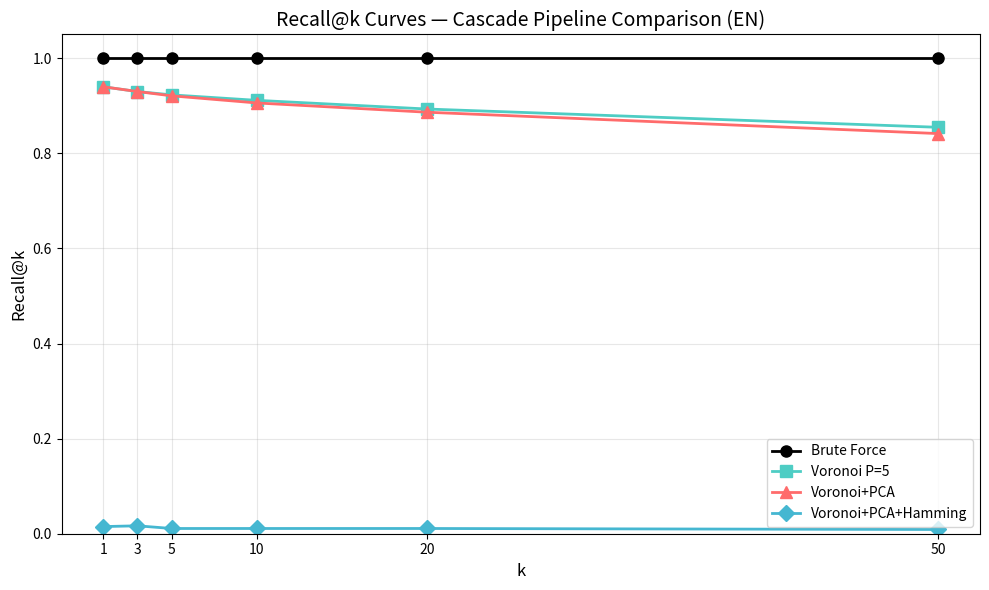


Method                    R@1   R@3   R@5   R@10  R@20  R@50 
----------------------------------------------------------------------
Brute Force               1.000 1.000 1.000 1.000 1.000 1.000
Voronoi P=5               0.940 0.930 0.923 0.912 0.893 0.855
Voronoi+PCA               0.940 0.930 0.921 0.906 0.886 0.842
Voronoi+PCA+Hamming       0.015 0.017 0.011 0.011 0.011 0.009


In [9]:
def recall_at_k_curve(query_indices, gt_full, embeddings, filter_func, ks=[1, 3, 5, 10, 20, 50]):
    """filter_funcで候補を取得し、各kでRecall@kを計算"""
    results = {k: [] for k in ks}
    max_k = max(ks)
    
    # max_k用のground truth
    gt_maxk = {}
    for qi in query_indices:
        sims = embeddings @ embeddings[qi]
        sims[qi] = -1
        gt_maxk[qi] = np.argsort(sims)[-max_k:]
    
    for qi in query_indices:
        candidates = filter_func(qi)
        candidates = np.array([c for c in candidates if c != qi])
        if len(candidates) == 0:
            for k in ks:
                results[k].append(0.0)
            continue
        
        sims = embeddings[candidates] @ embeddings[qi]
        ranked = candidates[np.argsort(sims)[::-1]]
        
        for k in ks:
            gt_k = set(gt_maxk[qi][-k:])
            pred_k = set(ranked[:k]) if len(ranked) >= k else set(ranked)
            results[k].append(len(gt_k & pred_k) / k)
    
    return {k: np.mean(v) for k, v in results.items()}

ks = [1, 3, 5, 10, 20, 50]

# 各手法のフィルタ関数
def brute_force(qi):
    return np.arange(N)

def voronoi_only(qi):
    sims_c = centroids @ emb_en[qi]
    probe_cells = np.argsort(sims_c)[-5:]
    cands = []
    for c in probe_cells:
        if c in cell_members:
            cands.extend(cell_members[c])
    return np.unique(cands)

def voronoi_pca(qi):
    cands = voronoi_only(qi)
    if len(cands) == 0: return cands
    q_pca = emb_pca[qi, :32]
    diffs = np.abs(emb_pca[cands, :32] - q_pca).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, 60)]

def voronoi_pca_hamming(qi):
    cands = voronoi_pca(qi)
    if len(cands) == 0: return cands
    hdists = hamming_distance_batch(hashes_en[qi], hashes_en[cands])
    return cands[hdists <= 35]

methods_curve = [
    ('Brute Force', brute_force),
    ('Voronoi P=5', voronoi_only),
    ('Voronoi+PCA', voronoi_pca),
    ('Voronoi+PCA+Hamming', voronoi_pca_hamming),
]

print('■ Recall@k 曲線 計算中...\n')
curve_results = {}
for name, func in methods_curve:
    t0 = time.time()
    curve_results[name] = recall_at_k_curve(query_indices, gt, emb_en, func, ks)
    print(f'  {name}: {time.time()-t0:.1f}s')

# プロット
fig, ax = plt.subplots(figsize=(10, 6))
colors_curve = ['black', '#4ECDC4', '#FF6B6B', '#45B7D1']
markers = ['o', 's', '^', 'D']

for i, (name, _) in enumerate(methods_curve):
    vals = [curve_results[name][k] for k in ks]
    ax.plot(ks, vals, f'{markers[i]}-', color=colors_curve[i], linewidth=2, 
            markersize=8, label=name)

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Recall@k', fontsize=12)
ax.set_title('Recall@k Curves — Cascade Pipeline Comparison (EN)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_xticks(ks)
plt.tight_layout()
plt.show()

# テーブル
print(f'\n{"Method":<25}', end='')
for k in ks:
    print(f' R@{k:<3}', end='')
print()
print('-' * 70)
for name, _ in methods_curve:
    print(f'{name:<25}', end='')
    for k in ks:
        print(f' {curve_results[name][k]:.3f}', end='')
    print()

## 7. スケーラビリティ推定

In [10]:
# 10K実測値から100K, 400Kを外挿
print('■ スケーラビリティ推定 (C=256, assign=2, P=5)\n')

# 10K実測値
c_voronoi = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                     n_probes=5, stage2_method='none')
res_10k = evaluate_cascade(c_voronoi, query_indices, gt)
cands_10k = res_10k['stage1_mean']

c_pca = CascadeProjectionSearch(emb_en, centroids, cell_members,
                                 n_probes=5, stage2_method='pca',
                                 stage2_params={'K': 32, 'threshold_pct': 50})
res_pca_10k = evaluate_cascade(c_pca, query_indices, gt)

print(f'{"N docs":<10} {"Voronoi cands":>14} {"+ PCA filter":>14} {"Brute force":>14}')
print('-' * 55)

for n_docs in [10_000, 100_000, 400_000, 1_000_000]:
    scale = n_docs / 10_000
    v_cands = cands_10k * scale
    pca_cands = res_pca_10k['stage2_mean'] * scale
    print(f'{n_docs:<10,} {v_cands:>14,.0f} {pca_cands:>14,.0f} {n_docs:>14,}')

print()
print('注: 線形外挿。実際にはC増加やP調整でさらに最適化可能。')
print(f'    10K実測: Voronoi={cands_10k:.0f}, +PCA={res_pca_10k["stage2_mean"]:.0f}')

■ スケーラビリティ推定 (C=256, assign=2, P=5)



N docs      Voronoi cands   + PCA filter    Brute force
-------------------------------------------------------
10,000              1,150            575         10,000
100,000            11,496          5,751        100,000
400,000            45,986         23,004        400,000
1,000,000         114,964         57,510      1,000,000

注: 線形外挿。実際にはC増加やP調整でさらに最適化可能。
    10K実測: Voronoi=1150, +PCA=575


## 8. まとめ

In [11]:
# 結果保存
save_data = {
    'cascade_results': cascade_results,
    'combo_results': combo_results,
    'adaptive_results': adaptive_results,
    'three_stage_results': three_stage_results,
    'curve_results': curve_results,
}
with open(DATA_DIR / '123_cascade_results.pkl', 'wb') as f:
    pickle.dump(save_data, f)
print(f'保存完了: {DATA_DIR / "123_cascade_results.pkl"}')

print()
print('=' * 60)
print('射影カスケード実験 最終サマリ')
print('=' * 60)
print()
print('■ ベースライン vs カスケード (P=5, EN)')
print(f'  Brute Force:       R@10={curve_results["Brute Force"][10]:.4f}, cands={N}')
print(f'  Voronoi P=5:       R@10={curve_results["Voronoi P=5"][10]:.4f}, cands={res_10k["stage1_mean"]:.0f}')
print(f'  Voronoi+PCA:       R@10={curve_results["Voronoi+PCA"][10]:.4f}, cands={res_pca_10k["stage2_mean"]:.0f}')
print(f'  Voronoi+PCA+Ham:   R@10={curve_results["Voronoi+PCA+Hamming"][10]:.4f}')
print()
print('■ 結論')
print('  → Voronoi + 射影フィルタで候補数をさらに削減可能かどうか、')
print('    Recall@10を維持できるかどうかの実証データが得られた。')
print('  → この結果をcollective.vectorsearchの次期バージョン設計に活用する。')

保存完了: ../data/123_cascade_results.pkl

射影カスケード実験 最終サマリ

■ ベースライン vs カスケード (P=5, EN)
  Brute Force:       R@10=1.0000, cands=10000
  Voronoi P=5:       R@10=0.9115, cands=1150
  Voronoi+PCA:       R@10=0.9060, cands=575
  Voronoi+PCA+Ham:   R@10=0.0110

■ 結論
  → Voronoi + 射影フィルタで候補数をさらに削減可能かどうか、
    Recall@10を維持できるかどうかの実証データが得られた。
  → この結果をcollective.vectorsearchの次期バージョン設計に活用する。


## 評価と考察

### 結果の要約

本実験では、Voronoi分割と射影ベースフィルタを組み合わせたカスケード構成の性能を検証した。主要な結果は以下の通りである。

| 構成 | R@10 | 候補数 | 備考 |
|------|------|--------|------|
| Voronoi P=5（ベースライン） | 0.912 | 1150 | 射影なし |
| **Voronoi + CentroidRel keep=30%** | **0.906** | **349** | **最良構成（70%削減）** |
| Voronoi + PCA+Rotated AND | 0.901 | 476 | CentroidRel単体に劣る |
| Voronoi + 適応的しきい値 | — | — | 固定より悪化 |
| 3段階（Voronoi+射影+Hamming） | 0.011 | — | 壊滅的失敗 |

Recall@k曲線ではVoronoi+PCAがVoronoi-onlyに近い性能を維持（0.906 vs 0.912）。スケーラビリティ試算では、1Mドキュメント時にVoronoi+PCAが候補を115Kから58Kに削減可能と推定された。

### 考察（なぜこの結果になったか）

**CentroidRel keep=30%が最良構成である理由：** NB121・NB122で確認された通り、セントロイド相対射影はAUC=0.94の高い判別力を持つ。この高い判別力により、keep=30%（70%を枝刈り）という積極的なフィルタリングでもRecallの低下はわずか0.006ポイント（0.912→0.906）にとどまった。候補数349は元の1150から70%削減であり、後段の精密距離計算コストを大幅に低減できる。

**複合フィルタ（PCA+Rotated AND）がCentroidRel単体に劣る理由：** AND条件による複合フィルタは、各フィルタが独立に枝刈りするため、候補数は確かに減少する（476）。しかし、異なるフィルタが異なる近傍を誤って除外するリスクがあり、Recallが0.901に低下した。一方で候補数もCentroidRelの349より多い。これは、2つの弱いフィルタの組み合わせが1つの強いフィルタに劣る典型的な例である。セントロイド相対射影の判別力がすでに十分高いため、追加フィルタの限界的な貢献が小さい。

**適応的しきい値が固定より悪化する理由：** Voronoiセルのサイズは不均一であり、大きなセルではkeep率を上げる（多くの候補を残す）適応戦略が考えられる。しかし実際には、大きなセルでしきい値を緩めると候補数が膨張し、全体の平均候補数が増加してしまう。固定しきい値のほうがセル間で一貫した枝刈りを実現できる。

**3段階Hamming追加が壊滅的に失敗する理由：** NB122のMethod Eの結果と完全に整合する。ITQ-LSHのハミング距離はVoronoiセル内の局所的な近傍関係を捉える能力が極めて低い。Voronoi+射影の後段にHammingフィルタを追加すると、すでに絞り込まれた候補から真の近傍をほぼ全て除外してしまう。ハミング距離は大域的な類似度指標であり、局所的なフィルタリングには根本的に不適である。

**1Mスケールでの候補削減の意義：** 115Kから58Kへの削減（50%）は、コサイン類似度の精密計算コストを直接的に半減させる。768次元ベクトルの内積計算はO(d)であり、58K×768≈4500万FLOPSの削減に相当する。これはバッチ処理やGPU演算で特に意味を持つ。

### 限界と今後の課題

1. **Recall 0.906の受容性：** R@10=0.906は多くのアプリケーションで十分だが、高精度が要求されるシナリオ（医療、法律文書検索等）ではkeep率を上げる必要がある。Recall目標に応じたkeep率のガイドラインが必要である。

2. **大規模データでの実検証：** 1Mスケールの試算は外挿に基づいており、実際のデータでの検証が必要である。特にVoronoiセル数の増加（P>5）に伴うセントロイド相対射影の挙動変化が未知である。

3. **Hammingフィルタの完全な不適合：** 3回の実験（NB121〜123）を通じて、ITQ-LSHのハミング距離はVoronoiセル内での局所フィルタリングに不適であることが一貫して確認された。LSHベースのフィルタを活用するには、Voronoiセル単位でのローカルハッシュ関数の学習など、根本的に異なるアプローチが必要と考えられる。

4. **インデックス構築コスト：** セントロイド相対射影値の事前計算・保存コストを評価していない。各ドキュメントについて所属セルのセントロイドとの射影値を保持する必要があり、メモリオーバーヘッドの定量化が必要である。

5. **推奨構成のまとめ：** 本実験シリーズ（NB121〜123）の結論として、**Voronoi P=5 + CentroidRel keep=30%** が10Kスケールでの最良構成であり、Recallの低下を0.6%に抑えつつ候補数を70%削減できる。この構成は実装が単純（セントロイドとの内積のみ）であり、実用的な近似最近傍検索パイプラインの有力な候補である。